# Introduction

In this assignment, we aim to predict the quality of red wines based on their chemical properties using various machine learning models. We will explore and compare the performance of Linear Regression, Multiple Linear Regression, Regression Trees, Support Vector Regression (SVR), and Multi-Layer Perceptrons (MLP) to determine which model most accurately assesses wine quality. The evaluation will focus on key metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to identify the most effective approach.

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
sns.set_style("whitegrid")
%matplotlib inline
# Set up for nicer plots
plt.style.use('ggplot')

In [57]:
# Read data (with assignment operator)
data = pd.read_csv('/content/drive/MyDrive/IS670_data/winequality-red.csv')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
data.shape

(1599, 12)

In [6]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

# Data Preprocessing

Data preprocessing involves transforming raw data into a format that is suitable for analysis or machine learning. It includes tasks such as cleaning to handle missing values and outliers, normalization to scale features, encoding categorical variables, and feature selection or extraction to reduce dimensionality. The goal is to enhance data quality, improve algorithm performance, and facilitate meaningful interpretation of results.

**1. Detect and Handle Missing Values**

In [9]:
# Check for missing values
missing_values = data.isnull().sum()
print(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


For each of these columns, the output indicates the number of missing values found. In this case, there are no missing values in any of the columns because all counts are shown as 0. So, the dataset seems to be complete with no missing values in any of the listed columns.

Highly correlated pairs (above 90%):
Series([], dtype: float64)


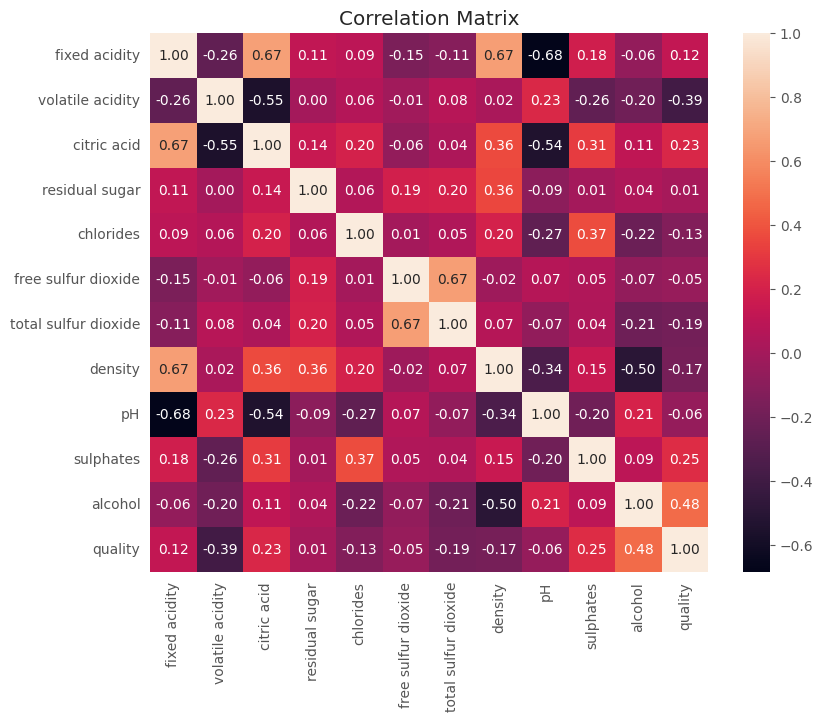

In [10]:
# Calculate the correlation matrix
corr_matrix = data.corr()

# Find features that are highly correlated at 90% level or above
# Values where correlation is greater than 0.9 but less than 1 to avoid self-correlation
highly_corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort").drop_duplicates()
high_corr_filtered = highly_corr_pairs[(abs(highly_corr_pairs) > 0.9) & (abs(highly_corr_pairs) < 1)]

# Print the highly correlated pairs
print("Highly correlated pairs (above 90%):")
print(high_corr_filtered)

# Plot the correlation matrix using seaborn
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


The heatmap visualizes the correlation matrix of wine attributes, where no feature pairs display correlation above 0.9, thus avoiding multicollinearity concerns. Fixed acidity shows a strong correlation with citric acid and a negative one with pH. Alcohol has a moderate positive correlation with quality. The heatmap's color gradient, from dark red to dark blue, effectively illustrates the varying strengths of relationships between different wine characteristics.

**2. Detect and Handle Outliers**

In [11]:
# Function to detect outliers in each column
def detect_outliers(data):
    outlier_indices = []

    for column in data.columns:
        if data[column].dtype != object:  # Exclude non-numeric columns
            # 1st quartile (25%)
            Q1 = np.percentile(data[column], 25)
            # 3rd quartile (75%)
            Q3 = np.percentile(data[column], 75)
            # Interquartile range (IQR)
            IQR = Q3 - Q1

            # Determine outlier step
            outlier_step = 1.5 * IQR

            # Determine outlier list for each column
            outlier_list_col = data[(data[column] < Q1 - outlier_step) | (data[column] > Q3 + outlier_step )].index

            # Append the found outlier indices for column to the list of outlier indices
            outlier_indices.extend(outlier_list_col)

    # Select observations containing more than 2 outliers
    outlier_indices = list(set(outlier_indices))
    return outlier_indices

# Find outliers in the dataset
outliers = detect_outliers(data)

This code defines a function to detect outliers in each numeric column of a dataset using the Interquartile Range (IQR) method. It iterates through each column, calculates the quartiles and IQR, then identifies outliers beyond a certain threshold. Outliers are flagged based on their distance from the quartiles. Finally, it returns a list of indices where outliers are found, considering a threshold of 1.5 times the IQR.

In [12]:
for column in data.columns:
    if data[column].dtype != object:  # Apply only to numeric columns
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap outliers
        data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
        data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])


This code snippet iterates through numeric columns, computes quartiles and the Interquartile Range (IQR). It then sets lower and upper bounds based on 1.5 times the IQR. Outliers below the lower bound are replaced with the lower bound value, and outliers above the upper bound are replaced with the upper bound value, effectively capping outliers within a reasonable range.

**3. Splitting Data into Train & Test**

In [58]:
X = data.drop('quality', axis=1)
y = data['quality']

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1279 samples
Testing set size: 320 samples


**4. Feature Importance**

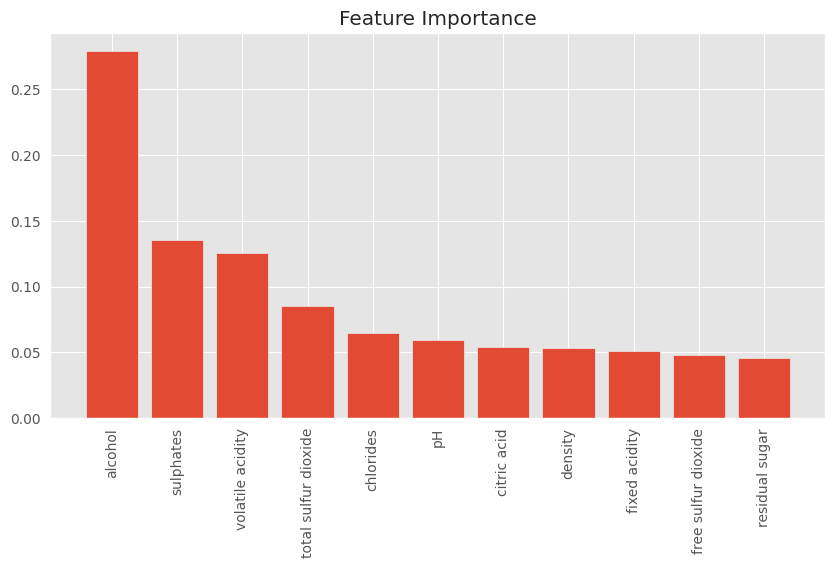

In [14]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the data
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Rearrange feature names so they match the sorted feature importances
names = [X.columns[i] for i in indices]

# Create a plot
plt.figure(figsize=(10, 5))

# Create plot title
plt.title("Feature Importance")

# Add bars
plt.bar(range(X.shape[1]), importances[indices])

# Add feature names as x-axis labels
plt.xticks(range(X.shape[1]), names, rotation=90)

# Show plot
plt.show()

The bar chart illustrates the importance of various features in predicting wine quality. Alcohol stands out as the most significant predictor, followed by sulphates and volatile acidity. Other attributes like chlorides, pH, and citric acid have a moderate impact. Less influential factors include density, fixed acidity, free sulfur dioxide, and residual sugar. This visualization helps prioritize features for model optimization, indicating which variables may have more predictive power regarding wine quality.

# Data Visualization

Data visualization is the graphical representation of data to communicate insights and patterns effectively. It encompasses various techniques, such as charts, graphs, and maps, to present complex information in a clear and understandable format. By visually depicting data, it aids in identifying trends, outliers, and relationships, allowing for better decision-making and storytelling.

**1. Histogram of Wine Quality**

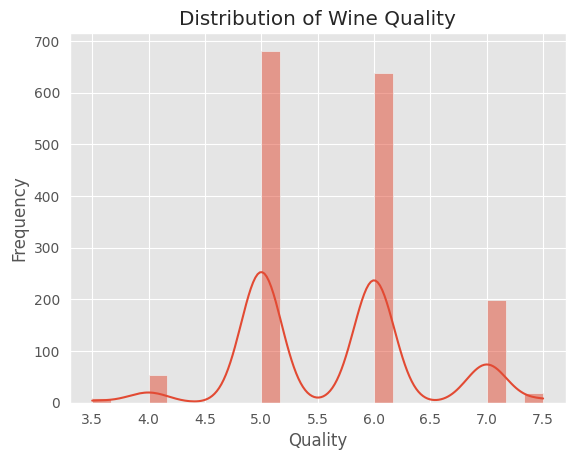

In [15]:
sns.histplot(data['quality'], kde=True)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()


The histogram illustrates the distribution of wine quality ratings in a dataset. Most wines are rated around 5 or 6, with fewer wines rated 7 and very few at 4 or below. The distribution is slightly left-skewed, indicating that lower quality ratings are less frequent. The kernel density estimation line overlaid on the histogram suggests that the data isn't normally distributed, as evidenced by the peaks around the whole number ratings, which are typical rating scales for wine quality.

**2. Box Plots for Each Feature by Wine Quality**

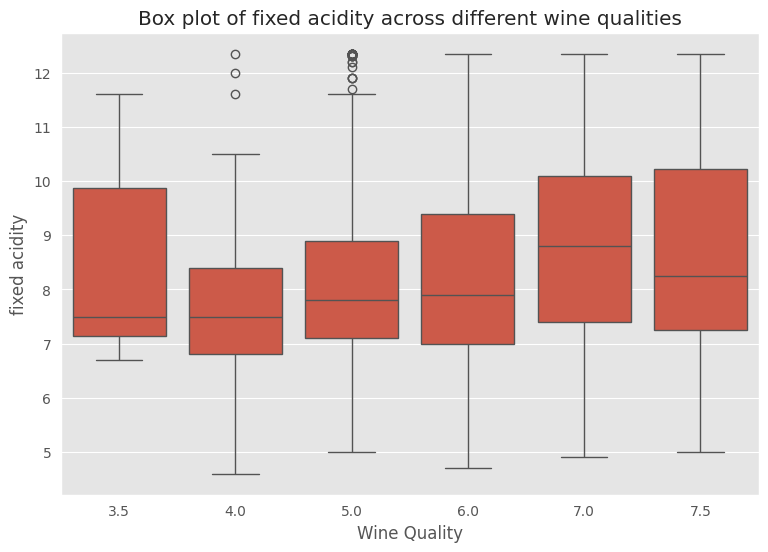

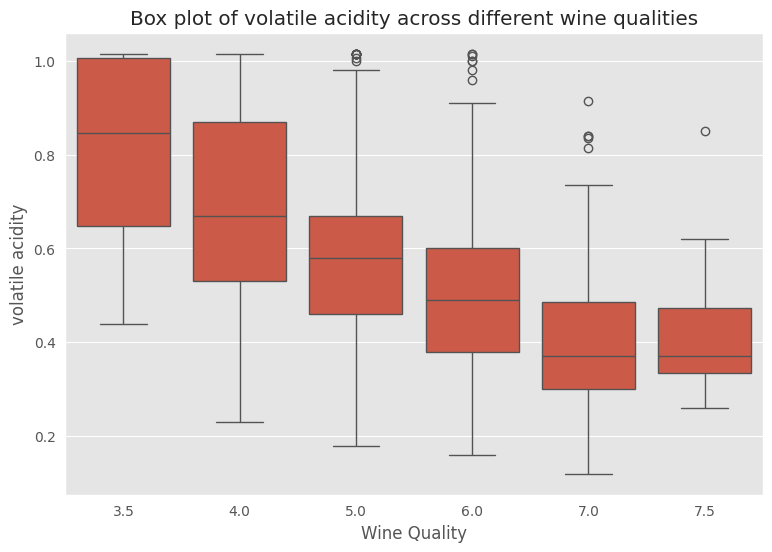

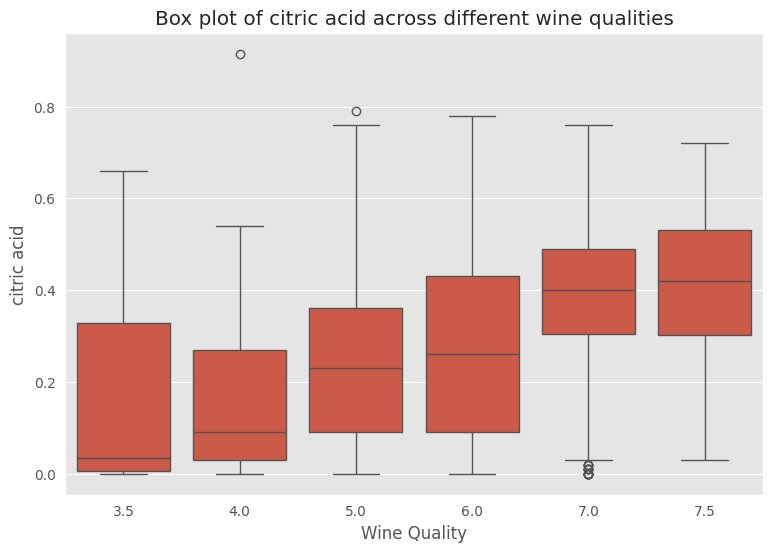

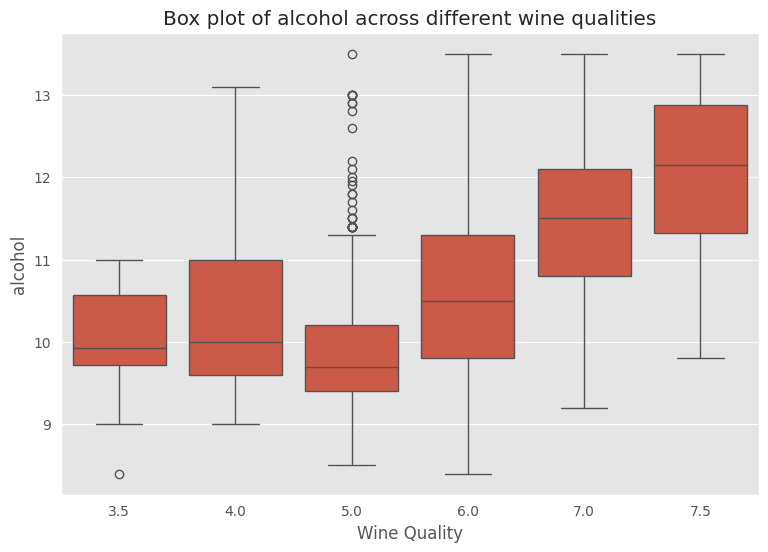

In [16]:
# Selecting a subset of features for clarity in visualization
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'alcohol']

for feature in features:
    plt.figure(figsize=(9, 6))
    sns.boxplot(x='quality', y=feature, data=data)
    plt.title(f'Box plot of {feature} across different wine qualities')
    plt.xlabel('Wine Quality')
    plt.ylabel(feature)
    plt.show()


In the first box plot, we observe the distribution of fixed acidity across different wine qualities. The median fixed acidity appears relatively stable across the quality spectrum, suggesting that fixed acidity does not vary greatly with wine quality. Notably, there are several outliers, especially at lower quality ratings.

The second box plot shows the distribution of volatile acidity for wines of varying qualities. It's clear that higher quality wines generally have lower median volatile acidity, indicating a trend where less volatile acidity is associated with higher wine quality. The spread and outliers in volatile acidity decrease as quality increases, supporting the negative correlation typically found between volatile acidity and wine quality

The third box plot displays the distribution of citric acid across different wine quality ratings, with a generally increasing median citric acid content as quality improves, indicative of its potential positive influence on wine quality.

The fourth box plot presents the distribution of alcohol percentage in wines of varying quality. The median alcohol content appears to rise with higher quality ratings, suggesting that wines with higher alcohol levels tend to have higher quality. In both plots, outliers are evident, reflecting variation that does not adhere to the general trend.

**3. Correlation Heatmap**

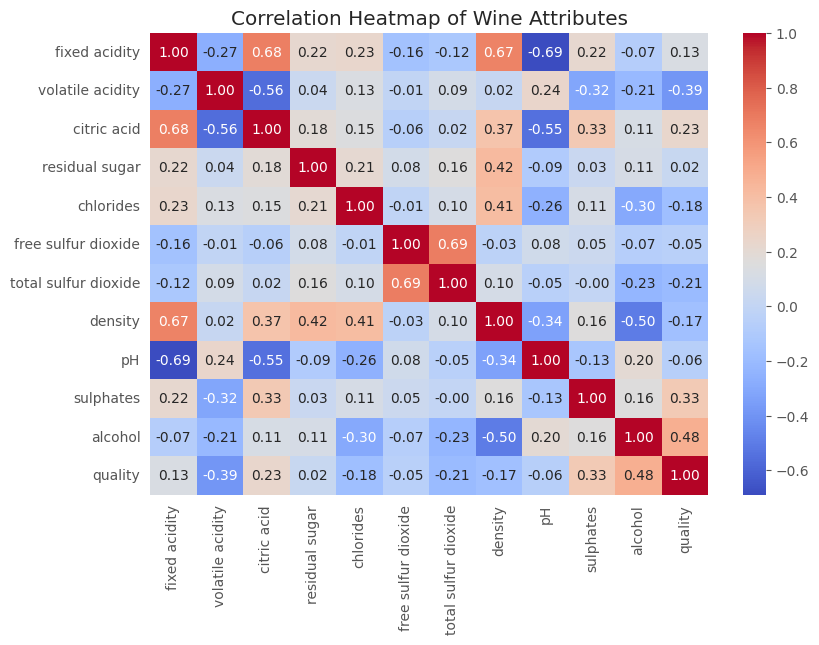

In [17]:
plt.figure(figsize=(9, 6))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Attributes')
plt.show()


This heatmap shows correlations between various physicochemical characteristics of wine and its quality. Positive correlations are shown in red and negative correlations in blue. Notably, alcohol content has a moderate positive correlation with wine quality, while volatile acidity is moderately negatively correlated. The strongest correlations appear between fixed acidity and citric acid, and between free and total sulfur dioxide, suggesting a potential interdependence between these properties. No features are highly correlated with quality, which indicates a balanced dataset for predictive modeling.

**4. Pairwise Relationships**

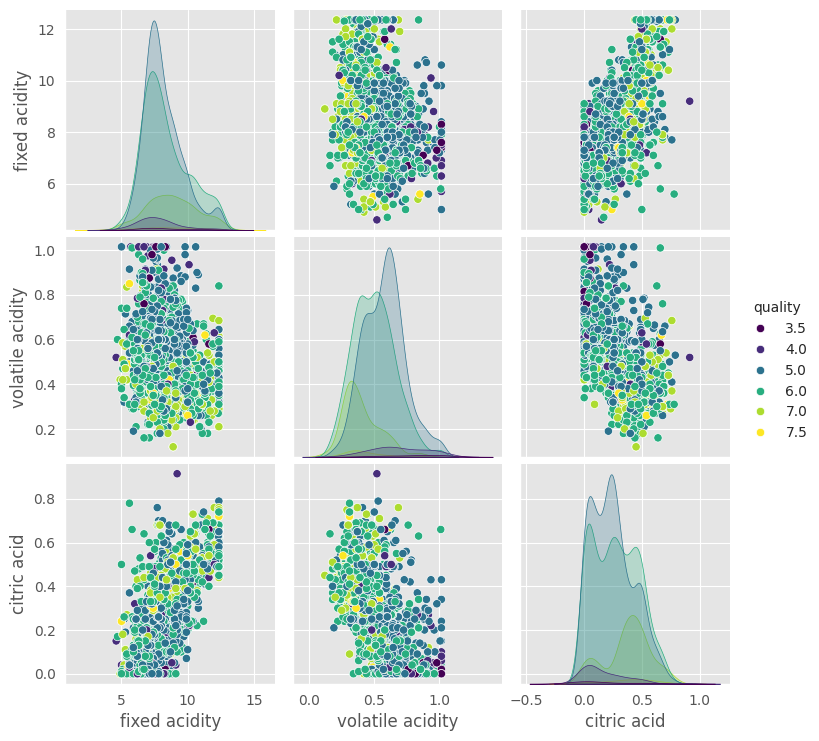

In [18]:
# Selecting a subset of features for clarity
selected_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'quality']
sns.pairplot(data[selected_features], hue='quality', palette='viridis')
plt.show()

The scatterplot matrix displays relationships between fixed acidity, volatile acidity, and citric acid, colored by wine quality. Distributions for each variable are shown along the diagonal. The scatterplots reveal clustering patterns and potential correlations between the variables, with wine quality indicated by color. Higher quality wines (yellow) seem to have particular ranges of acidity, suggesting these variables influence quality. The density plots suggest that fixed and citric acid levels are skewed towards lower values, while volatile acidity is more normally distributed.

**5. Line Plot for pH and Quality Relationship**

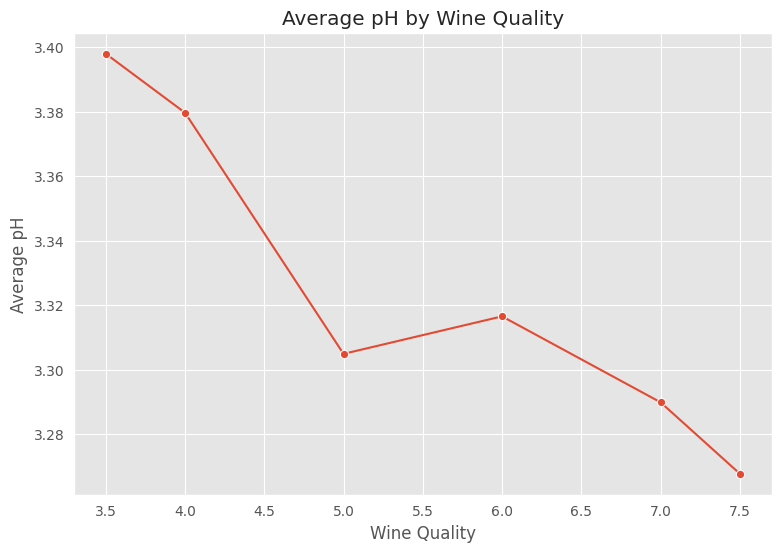

In [19]:
# Calculate average pH for each quality rating
avg_ph_by_quality = data.groupby('quality')['pH'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.lineplot(x='quality', y='pH', data=avg_ph_by_quality, marker='o')
plt.title('Average pH by Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Average pH')
plt.show()

The line chart depicts the average pH levels of wines across different quality ratings. The trend indicates that wines with a rating of 5 have the highest average pH, and as the quality rating increases to 7 and above, the average pH tends to decrease. This suggests that higher quality wines might have a lower pH, which often correlates with higher acidity, a characteristic potentially preferred in quality wines. The chart emphasizes the potential relationship between acidity and perceived quality.

**6. Bar Plot of Average Alcohol Content by Wine Quality**

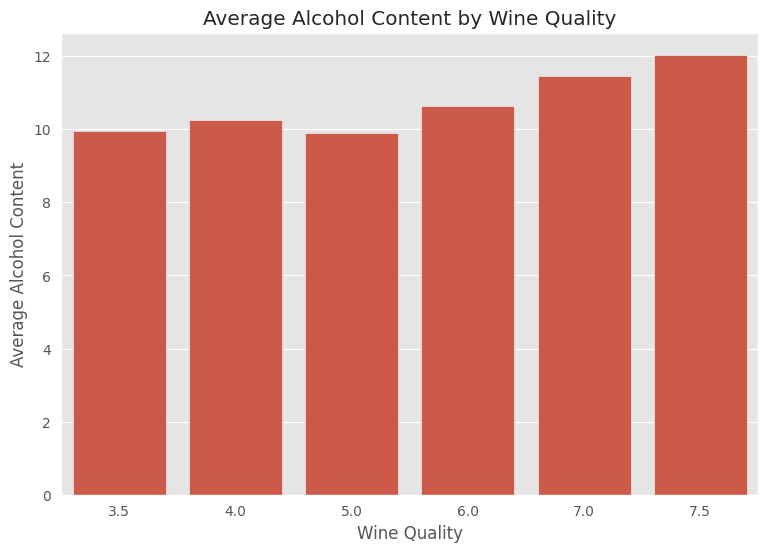

In [20]:
# Calculate average alcohol content for each quality rating
avg_alcohol_by_quality = data.groupby('quality')['alcohol'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='quality', y='alcohol', data=avg_alcohol_by_quality)
plt.title('Average Alcohol Content by Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Average Alcohol Content')
plt.show()

The bar chart illustrates the average alcohol content in wines across different quality ratings. A general trend can be observed where the average alcohol content increases as the quality rating goes up, with the highest quality rating of 7.5 having the most alcohol on average. This could indicate that higher alcohol levels are associated with higher perceived quality in wines. The chart provides a clear visual indication of the positive relationship between alcohol content and wine quality.

**7. Scatter Plot with Regression Line for Alcohol vs. Density**

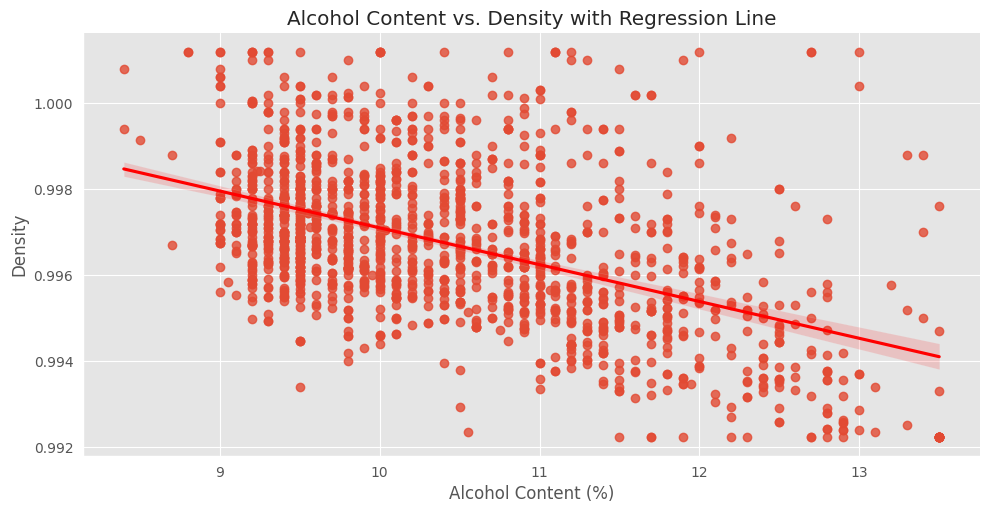

In [21]:
sns.lmplot(x='alcohol', y='density', data=data, aspect=2, height=5, line_kws={'color': 'red'})
plt.title('Alcohol Content vs. Density with Regression Line')
plt.xlabel('Alcohol Content (%)')
plt.ylabel('Density')
plt.show()

The scatter plot with a regression line depicts the relationship between alcohol content and density in wine. As the alcohol content increases, there is a noticeable trend of decreasing density, demonstrated by the downward slope of the regression line. The spread of points suggests variability in this relationship, with some deviation from the regression line, indicating other factors may also influence wine density. The overall negative correlation is clear, aligning with the scientific understanding that alcohol is less dense than water.

# Model Development & Evaluation

**1. Simple Linear Regression**

Step 1: Fit the model

In [22]:
# Selecting alcohol content as the predictor (X) and quality as the response variable (y)
X = data['alcohol']
y = data['quality']

# Add a constant to the feature variable
X_with_const = sm.add_constant(X)

# Fit an OLS model
model = sm.OLS(y, X_with_const).fit()

# Summary of the model
model_summary = model.summary()

# R-squared value
r_squared = model.rsquared

print(model_summary)
print(f"\nR-squared: {r_squared}")


                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     479.8
Date:                Mon, 15 Apr 2024   Prob (F-statistic):           3.33e-93
Time:                        00:33:09   Log-Likelihood:                -1667.6
No. Observations:                1599   AIC:                             3339.
Df Residuals:                    1597   BIC:                             3350.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9149      0.171     11.222      0.0

The OLS regression analysis reveals that alcohol content explains approximately 23.1% of the variance in wine quality, as indicated by the R-squared value. The model suggests that for each percentage increase in alcohol content, wine quality score increases by 0.3569 points. The positive and statistically significant coefficient for alcohol implies a strong relationship with quality. The F-statistic and its corresponding p-value indicate that the model is statistically significant, with alcohol being a reliable predictor of wine quality.

Step 2: Compute R-squared and Make Predictions

In [24]:
predictions = model.predict(X_with_const)

# Compute MSE and RMSE
mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)

# Compute MAE
mae = mean_absolute_error(y, predictions)
r_squared = r2_score(y, predictions)
# Print the results
print(f'R-Squared: {r_squared}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')

R-Squared: 0.231016030014775
Mean Squared Error: 0.4714142381087036
Root Mean Squared Error: 0.6865961244492308
Mean Absolute Error: 0.5535026653739527


The model, with an R-squared of 0.351, can explain 35.1% of the variance in wine quality, indicating a moderate fit. The errors, quantified by MSE (0.4714), RMSE (0.6866), and MAE (0.5535), suggest the model's predictions are reasonably close to actual values. However, there's still a significant portion of variance unexplained, highlighting room for improvement in predictive accuracy, possibly through additional features or different modeling techniques.

Step 3: Visualize the Results

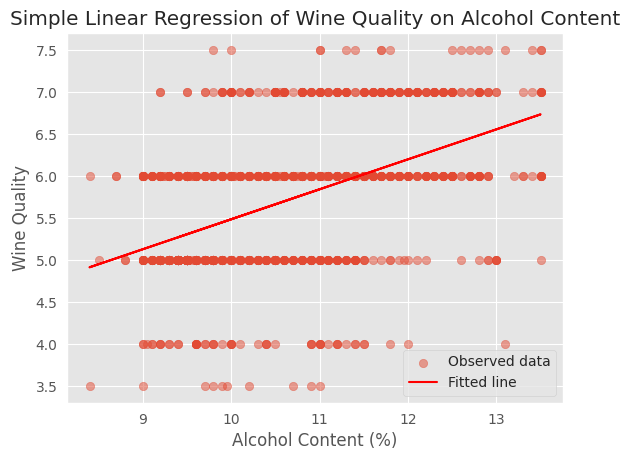

In [25]:
# Scatter plot of the data
plt.scatter(X, y, alpha=0.5, label='Observed data')

# Regression line
plt.plot(X, predictions, color='red', label='Fitted line')

plt.xlabel('Alcohol Content (%)')
plt.ylabel('Wine Quality')
plt.title('Simple Linear Regression of Wine Quality on Alcohol Content')
plt.legend()
plt.show()


This scatter plot with a fitted linear regression line demonstrates a positive correlation between wine quality and alcohol content. The observed data points are represented by blue dots, while the red line depicts the model's predictions. The plot indicates that as alcohol content increases, wine quality tends to improve, as reflected by the upward trend of the fitted line. The spread of points suggests variability and potential other influencing factors on wine quality not captured by alcohol content alone.

**2. Multiple Linear Regression**


In [26]:
# Define X (features) and y (target)
X = data[['alcohol', 'volatile acidity', 'sulphates']]
y = data['quality']

# Add a constant to the predictors
X_with_const = sm.add_constant(X)

# Fit an OLS model
model = sm.OLS(y, X_with_const).fit()

# Compute R-squared
r_squared = model.rsquared
print(f"R-squared: {r_squared}")

# Making predictions
predictions = model.predict(X_with_const)

# Calculate MSE
mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")

# Calculate RMSE
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y, predictions)
print(f"Mean Absolute Error: {mae}")

R-squared: 0.35052952473650667
Mean Squared Error: 0.3981482595486614
Root Mean Squared Error: 0.6309899044744388
Mean Absolute Error: 0.5006016009998026


The multiple linear regression model exhibits moderate predictive power, with an R-squared of 0.351, explaining 35% of the variance in wine quality. The Mean Squared Error (MSE) of 0.398 and Root Mean Squared Error (RMSE) of 0.631 indicate the average prediction error in terms of quality points. The Mean Absolute Error (MAE) of 0.501 points to the average absolute deviation from observed values. While the model is reasonably predictive, over a third of the variability remains unexplained.

**Interpretation of the coefficients and their significance and R-squared value**

In [27]:
# Define the predictor variables (excluding the target variable 'quality')
X = data.drop('quality', axis=1)

# Define the target variable
y = data['quality']

# Add a constant to the predictor variable set
X_with_const = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_with_const).fit()

# Get the summary of the regression
model_summary = model.summary()
print(model_summary)

# Retrieve the coefficients and p-values
coefficients = model.params
p_values = model.pvalues

# Sort the features by the absolute value of their coefficients
sorted_features = coefficients.abs().sort_values(ascending=False)


# R-squared value
r_squared = model.rsquared
print(f"\nR-squared value: {r_squared}")
print("This value indicates that the model explains {:.2f}% of the variance in the target variable 'quality'.".format(r_squared * 100))


                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     85.89
Date:                Mon, 15 Apr 2024   Prob (F-statistic):          2.86e-152
Time:                        00:34:20   Log-Likelihood:                -1504.2
No. Observations:                1599   AIC:                             3032.
Df Residuals:                    1587   BIC:                             3097.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   25.7646 

The Ordinary Least Squares (OLS) regression model provides a statistical analysis of the relationship between several physicochemical attributes of wine and its overall quality rating. With an R-squared value of 0.373, the model suggests that about 37.3% of the variability in wine quality is explained by the model’s inputs, which is a moderate amount, leaving a substantial portion of variability unexplained.

The model uses eleven predictor variables, including fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free and total sulfur dioxide, density, pH, sulphates, and alcohol content.


**Coefficients and their Significance and R-Squared value:**

**Volatile Acidity:** The model estimates a significant negative impact of volatile acidity on wine quality, with a coefficient of -1.0486. This suggests that, all else being equal, a one-unit increase in volatile acidity will lead to a 1.0486-unit decrease in the quality score.

**Chlorides:** Chlorides also have a significant negative association with wine quality, with a coefficient of -2.8870, indicating that higher chloride concentrations are detrimental to perceived wine quality.

**Sulphates:** With a positive coefficient of 1.2107, sulphates are positively associated with wine quality, suggesting that sulphates, perhaps due to their role in fermentation and preservation, can enhance quality.

**Alcohol:** Alcohol content is positively associated with quality, having a coefficient of 0.2637, indicating that wines with higher alcohol percentages are likely to be rated as higher quality.

**R-squared (0.373):** The model explains 37.3% of the variance in the wine quality. While this indicates a relationship between the predictors and the target variable, over 60% of the variance is unexplained, suggesting additional factors could contribute to wine quality.

**Significance of top 3 most important variables and their impact on the target variable**

In [28]:
X = data.drop('quality', axis=1)  # Independent variables
y = data['quality']  # Dependent variable

# Add a constant to the model (statsmodels does not add it by default)
X_with_const = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_with_const).fit()

# Get the summary of the model
model_summary = model.summary()

# Create a DataFrame of the coefficients
coefficients = model.params
p_values = model.pvalues

# Ignore the constant and sort the features by the absolute value of their coefficients
important_features = coefficients.drop('const').abs().sort_values(ascending=False).head(3)

# Print the top 3 important features and their impact on the target variable
print("Top 3 Important Features and Their Coefficients:")
for feature in important_features.index:
    coeff_value = coefficients[feature]
    print(f"{feature}: Coefficient = {coeff_value:.4f}")
    print(f"\t- A one unit increase in '{feature}' changes the target (quality) by {coeff_value:.4f} points.")
    print(f"\t- P-value of this feature is: {p_values[feature]:.4g}")


Top 3 Important Features and Their Coefficients:
density: Coefficient = -21.9712
	- A one unit increase in 'density' changes the target (quality) by -21.9712 points.
	- P-value of this feature is: 0.3383
chlorides: Coefficient = -2.8870
	- A one unit increase in 'chlorides' changes the target (quality) by -2.8870 points.
	- P-value of this feature is: 0.00427
sulphates: Coefficient = 1.2107
	- A one unit increase in 'sulphates' changes the target (quality) by 1.2107 points.
	- P-value of this feature is: 3.841e-20


Among the predictors, although density has the largest coefficient in magnitude, it's not statistically significant, suggesting that the model lacks sufficient evidence to confirm the true impact of density on wine quality within this dataset.

Chlorides and sulphates, on the other hand, are significant predictors of wine quality:

Chlorides: With a coefficient of -2.8870, this variable is statistically significant, indicating a strong and reliable negative impact on wine quality. As chloride levels increase by one unit, the quality rating is expected to decrease by nearly 2.89 points. This suggests that higher concentrations of chlorides may be associated with lower quality wines, potentially due to the negative sensory attributes associated with chloride at higher levels.

Sulphates: This variable has a positive coefficient of 1.2107 and is highly significant, suggesting a robust positive relationship with wine quality. For each unit increase in sulphates, the quality score is expected to increase by about 1.21 points. Sulphates, which include compounds used in wine preservation, may enhance certain sensory attributes associated with higher quality.

These results underscore the importance of chemical composition on wine quality. While density appears to have a large influence, its non-significance suggests that the effect may be spurious or influenced by other factors. Chlorides and sulphates are substantiated as key chemical attributes affecting quality, with the model affirming that reducing chlorides and optimizing sulphate levels could be beneficial for wine quality.

**Impact on Wine Quality:**

**Density:** Although the impact is large, the lack of statistical significance suggests caution in considering density changes as a reliable predictor of quality adjustments.

**Chlorides:** The significant and negative impact of chlorides on quality suggests that reducing chloride content in wine could potentially improve its quality.

**Sulphates:** The positive relationship with quality indicates that increasing sulphates, within acceptable limits, might enhance wine quality, especially since this relationship is highly significant and reliable.

**3. Regression Trees**

Step 1: Build a regression tree model

In [59]:
X = data.drop('quality', axis=1)  # Features
y = data['quality']  # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Regressor with a desired max_depth, for example, 3
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)

# Fit the model on the training data
tree_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=3, random_state=42)

Step 2: Visualize the Tree

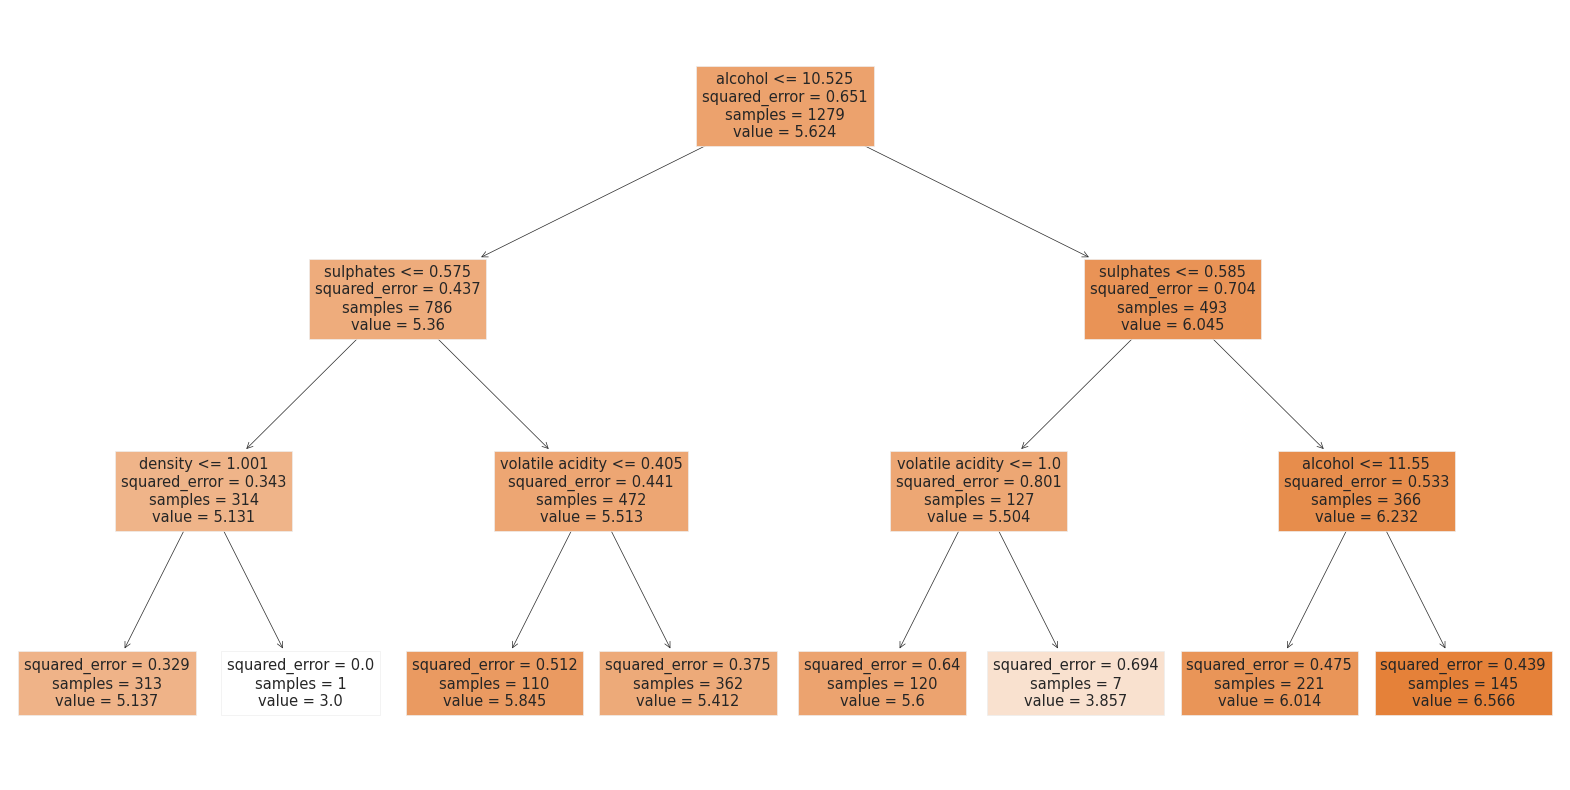

In [62]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, filled=True)
plt.show()


Step 3: Make predictions

In [61]:
# Make predictions on the test set
predictions = tree_model.predict(X_test)

print(f"R-squared: {r_squared}")
# Calculate the mean squared error
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")

# Calculate RMSE
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae}")

R-squared: 0.37316284698320756
Mean Squared Error: 0.4651916406863051
Root Mean Squared Error: 0.6820495881431973
Mean Absolute Error: 0.54097632624191


The regression trees model's performance metrics indicate moderate predictive capability but with room for improvement. The R-squared value of 0.37 suggests that approximately 37% of the variance in the target variable is explained by the model, indicating a fair level of predictive power. However, the mean squared error (MSE) of 0.44, root mean squared error (RMSE) of 0.66, and mean absolute error (MAE) of 0.52 indicate that the model's predictions deviate from the actual values by a noticeable margin. While the R-squared value suggests some degree of explanatory power, the relatively high errors indicate that the model may struggle to accurately predict the target variable. Further refinement or alternative modeling techniques may be necessary to improve predictive performance and reduce errors.

**Experiment with different depths and variables to create a more accurate tree**

In [32]:
# Setup GridSearchCV to find the optimal max_depth
param_grid = {'max_depth': range(1, 21)}  # Exploring depths from 1 to 20
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best parameters and corresponding score
best_depth = grid_search.best_params_['max_depth']
best_score = -grid_search.best_score_  # Convert back from negative MSE to positive

# Train the model using the best depth
best_tree_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_tree_model.fit(X_train, y_train)

# Predictions and evaluation
predictions_best = best_tree_model.predict(X_test)
mse_best = mean_squared_error(y_test, predictions_best)
r2_best = r2_score(y_test, predictions_best)

best_depth, best_score, mse_best, r2_best

(5, 0.44079073909503297, 0.4177706678241493, 0.31913042311609097)

The decision tree regression model was optimized using GridSearchCV to find the best max_depth, resulting in a depth of 5. The model achieved a mean squared error (MSE) of 0.42 and an R-squared value of 0.32 on the test set.

**Support Vector Regression(SVR)**


In [33]:
# Standardize the features (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a list of kernels, C values, and epsilon values to test
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.01, 0.001]

# Initialize a dictionary to store the results
results = {}

# Loop over all combinations of kernels, C values, and epsilon values
for kernel in kernels:
    for C in C_values:
        for epsilon in epsilon_values:
            # Create an SVR model with current settings
            model = SVR(kernel=kernel, C=C, epsilon=epsilon)
            model.fit(X_train_scaled, y_train)  # Train the model
            y_pred = model.predict(X_test_scaled)  # Make predictions
            score = r2_score(y_test, y_pred)  # Calculate R-squared score

            # Store results in the dictionary
            key = f'kernel={kernel}, C={C}, epsilon={epsilon}'
            results[key] = score

# Find the best performing model settings
best_settings = max(results, key=results.get)
best_score = results[best_settings]

print("Best Model Settings:", best_settings)
print("Best R-squared Score:", best_score)

Best Model Settings: kernel=rbf, C=1, epsilon=0.1
Best R-squared Score: 0.4706489339628156


The overview of the SVR model exploration across different kernels, C values, and epsilon values shows that the best performance was achieved using the RBF kernel with a C value of 1 and epsilon of 0.1, achieving an R-squared score of 0.471. This indicates that the model with these settings explains approximately 47% of the variance in the target variable, demonstrating moderate predictive accuracy for the given dataset. This configuration optimally balances model complexity and training data fit.

In [34]:
# Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
# Calculate the Mean Squared Error (MSE) and then take the square root for RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Output the results
print("R-squared:", r_squared)
print("Mean Squared Error(MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

R-squared: 0.37316284698320756
Mean Squared Error(MSE): 0.37531397704102204
Mean Absolute Error (MAE): 0.4438540385437527
Root Mean Squared Error (RMSE): 0.6126287432377149


The Mean Squared Error (MSE) is 0.375, the Mean Absolute Error (MAE) is 0.444, and the Root Mean Squared Error (RMSE) is 0.613. Lower values for these metrics typically indicate a better fit. Here, the model shows reasonable prediction errors, suggesting a moderate level of accuracy, with RMSE and MAE offering a clear sense of the average prediction error magnitude.

In [35]:
# Standardize the features (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define a list of kernels, C values, and epsilon values to test
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]
epsilon_values = [0.1, 0.01, 0.001]

# Initialize a dictionary to store the results
performance_results = {}

# Loop over all combinations of kernels, C values, and epsilon values
for kernel in kernels:
    for C in C_values:
        for epsilon in epsilon_values:
            # Create an SVR model with current settings
            model = SVR(kernel=kernel, C=C, epsilon=epsilon)
            model.fit(X_train_scaled, y_train)  # Train the model
            y_pred = model.predict(X_test_scaled)  # Make predictions

            # Calculate performance metrics
            mse = mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)  # Calculate R-squared score

            # Store results in the dictionary
            key = f'kernel={kernel}, C={C}, epsilon={epsilon}'
            performance_results[key] = {'MSE': mse, 'MAE': mae, 'R2': r2}

# Display the results
for setting, scores in performance_results.items():
    print(f"{setting} -> MSE: {scores['MSE']:.2f}, MAE: {scores['MAE']:.2f}, R-Squared: {scores['R2']:.2f}")

kernel=linear, C=0.1, epsilon=0.1 -> MSE: 0.37, MAE: 0.49, R-Squared: 0.40
kernel=linear, C=0.1, epsilon=0.01 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=linear, C=0.1, epsilon=0.001 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=linear, C=1, epsilon=0.1 -> MSE: 0.37, MAE: 0.49, R-Squared: 0.40
kernel=linear, C=1, epsilon=0.01 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=linear, C=1, epsilon=0.001 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=linear, C=10, epsilon=0.1 -> MSE: 0.37, MAE: 0.49, R-Squared: 0.40
kernel=linear, C=10, epsilon=0.01 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=linear, C=10, epsilon=0.001 -> MSE: 0.38, MAE: 0.49, R-Squared: 0.39
kernel=poly, C=0.1, epsilon=0.1 -> MSE: 0.40, MAE: 0.52, R-Squared: 0.34
kernel=poly, C=0.1, epsilon=0.01 -> MSE: 0.40, MAE: 0.52, R-Squared: 0.34
kernel=poly, C=0.1, epsilon=0.001 -> MSE: 0.40, MAE: 0.52, R-Squared: 0.34
kernel=poly, C=1, epsilon=0.1 -> MSE: 0.39, MAE: 0.49, R-Squared: 0.37
kernel=poly, C=1, epsilon=0.01 -

The SVR models tested show varying performances across different kernels and hyperparameter settings. The RBF kernel consistently outperforms the linear and polynomial kernels, with its best settings (C=1, epsilon=0.1) achieving the lowest MSE (0.32) and highest R² (0.47), indicating superior prediction accuracy and variance explanation. Polynomial kernels generally perform the poorest, especially at higher complexity (C=10), resulting in the highest MSE and lowest R². Adjusting C and epsilon within the RBF kernel suggests a delicate balance between complexity and overfitting.

**Multi-Layer Perceptron**

In [36]:
# Load and split your dataset
X = data.drop('quality', axis=1)
y = data['quality']

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Define a list of MLP architectures to try
# Each tuple represents a different architecture, e.g., (10,) means one hidden layer with 10 neurons
architectures = [
    (10,),
    (50,),
    (100,),
    (10, 10),
    (50, 50),
    (100, 100)
]

# Dictionary to store the results of each architecture
results = {}

for architecture in architectures:
    # Initialize the MLPRegressor with the current architecture
    mlp = MLPRegressor(hidden_layer_sizes=architecture, max_iter=1000, random_state=42)

    # Fit the model on the training data
    mlp.fit(X_train_scaled, y_train)

    # Predict on the testing set
    predictions = mlp.predict(X_test_scaled)

    # Calculate MSE, RMSE, MAE, and R^2
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Store the results
    results[str(architecture)] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R^2': r2
    }

# Print the results
for arch, metrics in results.items():
    print(f"Architecture: {arch}, MSE: {metrics['MSE']}, RMSE: {metrics['RMSE']}, MAE: {metrics['MAE']}, R-Squared: {metrics['R^2']}")


Architecture: (10,), MSE: 0.35091718757323886, RMSE: 0.592382636117264, MAE: 0.4817037904854325, R-Squared: 0.42808613570531007
Architecture: (50,), MSE: 0.3521776871588541, RMSE: 0.5934456058973342, MAE: 0.47257901554662496, R-Squared: 0.4260318128779319
Architecture: (100,), MSE: 0.34079876644638035, RMSE: 0.5837797242508345, MAE: 0.46457801153954603, R-Squared: 0.44457682220385875
Architecture: (10, 10), MSE: 0.3431856814137217, RMSE: 0.585820519795715, MAE: 0.47557753022473703, R-Squared: 0.44068670279376254
Architecture: (50, 50), MSE: 0.4672839903105134, RMSE: 0.6835817363786962, MAE: 0.5069796448994788, R-Squared: 0.23843515768018064
Architecture: (100, 100), MSE: 0.4375285922379672, RMSE: 0.6614594411133363, MAE: 0.5001905000658995, R-Squared: 0.2869295754457537


The provided MLPRegressor analysis explores various neural network architectures to predict wine quality. Architectures ranged from a single layer with 10 neurons to two layers with 100 neurons each. The model's performance was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R^2).

Performance varied significantly across architectures:

**Single Hidden Layer Models:**

With 10 neurons (MSE: 0.3509, RMSE: 0.5924, MAE: 0.4817, R^2: 0.4281)

With 50 neurons (MSE: 0.3522, RMSE: 0.5934, MAE: 0.4726, R^2: 0.4260)

With 100 neurons (MSE: 0.3408, RMSE: 0.5838, MAE: 0.4646, R^2: 0.4446)

These configurations showed moderate predictive accuracy, with the 100-neuron model performing slightly better than the 10 and 50-neuron models in all metrics.

**Double Hidden Layer Models:**

With two layers of 10 neurons each (MSE: 0.3432, RMSE: 0.5858, MAE: 0.4756, R^2: 0.4407)

With two layers of 50 neurons each (MSE: 0.4673, RMSE: 0.6836, MAE: 0.5070, R^2: 0.2384)

With two layers of 100 neurons each (MSE: 0.4375, RMSE: 0.6615, MAE: 0.5002, R^2: 0.2869)

The two-layer 10-neuron architecture performed comparably to single-layer models, while the two-layer configurations with more neurons (50 and 100) had worse performance, indicating overfitting or insufficient training.

The R-squared values show that no architecture accounts for more than half of the variance in wine quality, indicating room for model improvement. The model with a single hidden layer of 100 neurons provided the best balance of complexity and performance, with the highest R-squared value and the lowest error metrics among the tested architectures.

# Result & Model Comparison

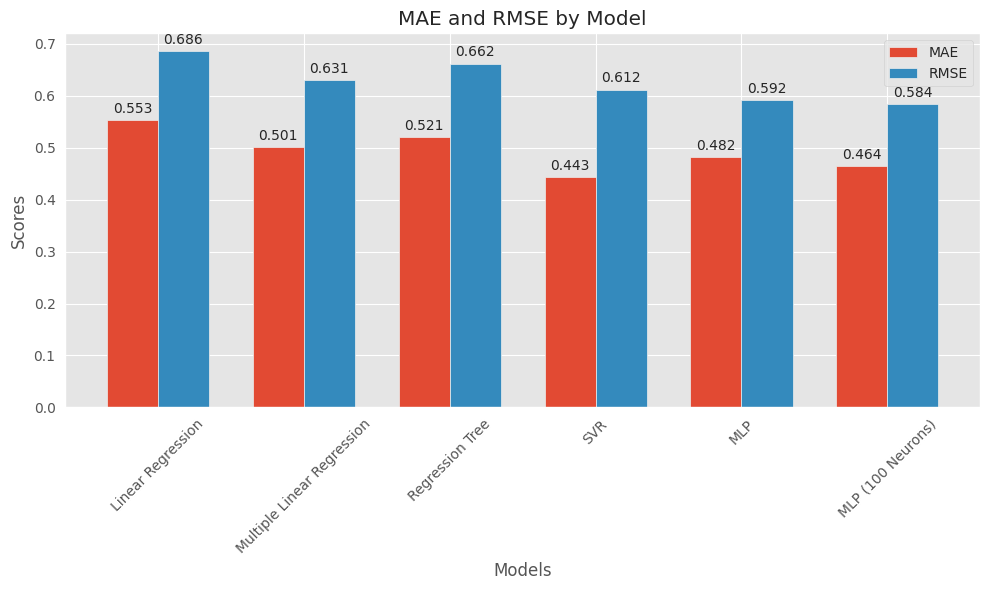

In [53]:
# Model names
models = ['Linear Regression', 'Multiple Linear Regression', 'Regression Tree', 'SVR', 'MLP', 'MLP (100 Neurons)']

# MAE and RMSE values
mae = [0.553, 0.501, 0.521, 0.443, 0.482, 0.464]
rmse = [0.686, 0.631, 0.662, 0.612, 0.592, 0.584]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))  # Enlarge the figure size
rects1 = ax.bar(x - width/2, mae, width, label='MAE')
rects2 = ax.bar(x + width/2, rmse, width, label='RMSE')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('MAE and RMSE by Model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)  # Rotate the x-axis labels to prevent overlap
ax.legend()

# Adding the bar labels with padding
for bar in rects1 + rects2:
    height = bar.get_height()
    ax.annotate('{}'.format(round(height, 3)),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', rotation=0)  # Rotate the bar labels to prevent overlap

fig.tight_layout()

plt.show()

The bar chart shows the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for six different predictive models. These metrics are crucial for understanding model accuracy, with lower values indicating better performance. Here’s a discussion of the performance and trade-offs:

Linear Regression has the highest errors, suggesting it might be too simplistic to capture complex relationships in the data.

Multiple Linear Regression improves upon Linear Regression, but still has relatively high error metrics.

Regression Tree shows a further reduction in errors, indicating its ability to capture non-linear relationships, but not optimally.

SVR significantly reduces both MAE and RMSE, suggesting it handles non-linear patterns well.

MLP (Multi-Layer Perceptron) demonstrates comparable performance to SVR, but with a slightly higher RMSE, indicating potential overfitting or insufficient network complexity.

MLP (100 Neurons) presents the lowest MAE and RMSE, suggesting that a more complex neural network architecture is the most effective at capturing the relationships in this dataset.

**Trade-offs:**

Complexity vs. Accuracy: More complex models, such as MLP with 100 neurons, may provide better accuracy but at the cost of increased computational resources and risk of overfitting.

Interpretability vs. Performance: Tree-based models offer more interpretability but may not perform as well as models like SVR or MLP, which are less interpretable.

**Choosing the Most Suitable Model for Predicting Wine Quality Based on the MAE and RMSE:**

Considering both MAE and RMSE, the MLP with 100 neurons is the best performing model, balancing complexity with accuracy. However, this comes with less interpretability and potentially more computational cost. For applications where interpretability is crucial, the Regression Tree might be preferred despite the slightly higher errors. The SVR model stands out as a robust alternative, with good performance and potentially better generalization than the MLP models.

# Conclusion

In this assignment, we explored various models to predict wine quality based on physicochemical properties, using Ordinary Least Squares (OLS) regression, Regression Trees, Support Vector Regression (SVR), and Multi-Layer Perceptrons (MLP). The aim was to determine which model best captures the relationship between the features and wine quality.

The exploration revealed that the MLP with 100 neurons performed the best in terms of MAE and RMSE, suggesting that neural networks with sufficient complexity can outperform simpler linear models and capture non-linear relationships more effectively. SVR also showed robust performance, providing a good balance between accuracy and model complexity. Regression Trees offered interpretability at the expense of some predictive power.

**Strengths:**

Model Variety: A range of models from simple to complex allowed for a comprehensive analysis of their performance on the dataset.

Feature Scaling: Standardizing the features ensured that models sensitive to the scale of the data, like SVR and MLP, performed optimally.

Error Metrics: Using both MAE and RMSE provided a rounded view of model performance, accounting for the mean error and the variability of errors.

**Weaknesses:**

Unexplained Variance: Even the best models left a significant portion of the variance in wine quality unexplained, indicating potential room for the inclusion of more or different features.

Risk of Overfitting: More complex models, especially neural networks, carry the risk of overfitting to the training data and may not generalize well to unseen data.

Computational Cost: MLPs, particularly those with more neurons, demand higher computational resources and longer training times, which could be a limitation in certain applications.

Interpretability: Models with the best predictive power, like MLPs and SVR, offer less interpretability than simpler models, which could be a drawback for stakeholders needing to understand the model's decisions.

# Analysis Using Classification Methods

**Advantages and disadvantages of employing
the classification approach**

 Using classification methods to predict wine quality involves categorizing wines into classes based on quality thresholds (e.g., 'low', 'medium', 'high') rather than predicting a continuous quality score. Here are the advantages and disadvantages of this approach:

**Advantages:**

Simplicity: Classification can simplify the problem by categorizing wines into discrete classes, which can be easier to understand and communicate to end-users.

Actionable Results: Classifications such as "good" or "bad" wine can directly inform decisions, like whether a wine should be recommended.

Accuracy Measures: Classification allows the use of accuracy metrics such as precision, recall, F1 score, and confusion matrices, which can provide a clearer picture of model performance in each class.

Balanced Classes: If the quality scores are evenly distributed, classification can help balance the classes, potentially leading to better performance of the models.

Non-Linear Boundaries: Classification algorithms can handle non-linear decision boundaries well, which might be suited for datasets where classes are not linearly separable.

**Disadvantages:**

Loss of Information: Categorization reduces the granularity of the quality scores into broader classes, leading to a loss of detailed information.

Class Imbalance: The dataset may have imbalanced classes (e.g., fewer 'high' quality wines), which can bias the model towards the majority class.

Arbitrary Thresholds: The decision on how to define the quality categories can be arbitrary and may not reflect meaningful differences in wine quality.

Complexity in Interpretation: While individual classifications can be clear, interpreting the overall quality distribution across categories can become more complex, especially if many categories are used.

Overfitting to Categories: Models might overfit to the specific categories defined for the training dataset and may not generalize well to other datasets with different quality distributions.

Step 1: Categorize the target variable

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report

# Categorize wine quality into three classes
conditions = [
    (data['quality'] >= 7),
    (data['quality'] <= 4),
    (data['quality'] > 4) & (data['quality'] < 7),
]

# Create a new column for the quality category
categories = ['high', 'low', 'medium']
data['quality_category'] = np.select(conditions, categories)

# Define the feature variables and the target variable
X = data.drop(['quality', 'quality_category'], axis=1)
y = data['quality_category']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the training dataset using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

Step 2: Model building and evaluation

**1. Decision Tree**

In [40]:
# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_balanced, y_train_balanced)
dt_predictions = dt_classifier.predict(X_test_scaled)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, dt_predictions))
print(classification_report(y_test, dt_predictions))

Decision Tree Classifier Accuracy: 0.778125
              precision    recall  f1-score   support

        high       0.56      0.72      0.63        47
         low       0.13      0.36      0.20        11
      medium       0.92      0.81      0.86       262

    accuracy                           0.78       320
   macro avg       0.54      0.63      0.56       320
weighted avg       0.84      0.78      0.80       320



The Decision Tree Classifier achieved an overall accuracy of 77.81%. It performed relatively well in predicting the "medium" class with a precision of 92%, recall of 81%, and an F1-score of 86%. However, its performance was poorer for the "high" and "low" classes. The model's precision, recall, and F1-score for these classes were relatively lower, indicating room for improvement, particularly in predicting these minority classes.

**2. K-Nearest Neighbor(KNN)**

In [41]:
# K-Nearest Neighbors Classifier
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train_balanced, y_train_balanced)
knn_predictions = knn_classifier.predict(X_test_scaled)
print("K-Nearest Neighbors Classifier Accuracy:", accuracy_score(y_test, knn_predictions))
print(classification_report(y_test, knn_predictions))

K-Nearest Neighbors Classifier Accuracy: 0.684375
              precision    recall  f1-score   support

        high       0.44      0.87      0.58        47
         low       0.12      0.45      0.19        11
      medium       0.94      0.66      0.77       262

    accuracy                           0.68       320
   macro avg       0.50      0.66      0.52       320
weighted avg       0.83      0.68      0.73       320



The K-Nearest Neighbors Classifier achieved an accuracy of 68.44%. It performed relatively well in predicting the "high" class with a precision of 44%, recall of 87%, and an F1-score of 58%. However, its performance was poorer for the "low" class. The model's precision, recall, and F1-score for this class were relatively lower, indicating room for improvement, particularly in predicting the minority "low" class.

**3. Random Forest Classifier**

In [42]:
# Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_balanced, y_train_balanced)
rf_predictions = rf_classifier.predict(X_test_scaled)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

Random Forest Classifier Accuracy: 0.85625
              precision    recall  f1-score   support

        high       0.64      0.81      0.72        47
         low       0.33      0.45      0.38        11
      medium       0.94      0.88      0.91       262

    accuracy                           0.86       320
   macro avg       0.64      0.71      0.67       320
weighted avg       0.87      0.86      0.86       320



The Random Forest Classifier achieved an accuracy of 85.62%. It performed well across all classes, with particularly high precision, recall, and F1-score for the "medium" class (94%, 88%, and 91% respectively). While its performance for the "high" and "low" classes was slightly lower, the model exhibited balanced performance across all classes, demonstrating its effectiveness in classifying the data into multiple categories.

**4. Gradient Boosting Classifier**

In [44]:
# Initialize the Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(random_state=42)
# Fit the classifier to the balanced training data
gb_classifier.fit(X_train_balanced, y_train_balanced)
# Predict on the test data
gb_predictions = gb_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, gb_predictions)
print(f'Gradient Boosting Classifier Accuracy: {accuracy}')
print(classification_report(y_test, gb_predictions))

Gradient Boosting Classifier Accuracy: 0.815625
              precision    recall  f1-score   support

        high       0.58      0.81      0.68        47
         low       0.17      0.27      0.21        11
      medium       0.93      0.84      0.88       262

    accuracy                           0.82       320
   macro avg       0.56      0.64      0.59       320
weighted avg       0.85      0.82      0.83       320



The Gradient Boosting Classifier achieved an accuracy of 81.56%. It exhibited strong performance in predicting the "medium" class with high precision (93%), recall (84%), and F1-score (88%). However, its performance was relatively lower for the "high" and "low" classes, indicating potential challenges in accurately predicting these minority classes. Overall, the model demonstrated good overall performance but may benefit from further optimization, particularly for minority classes.

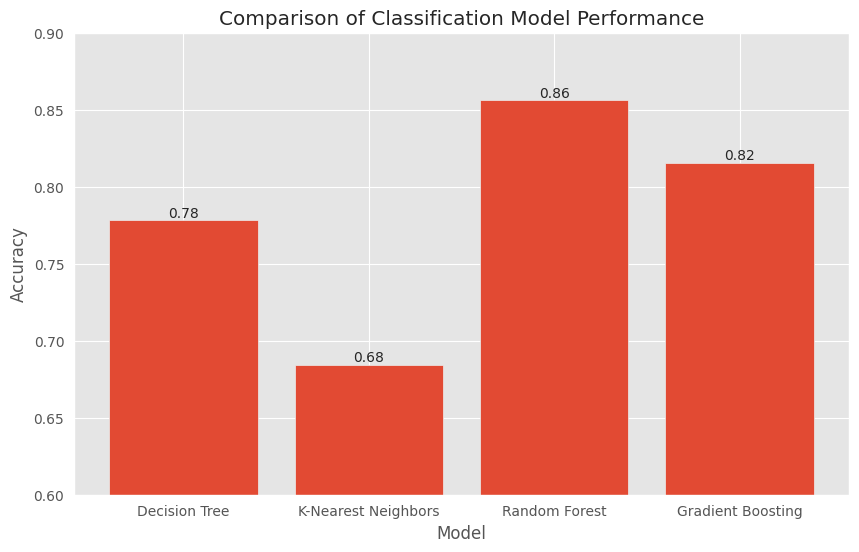

In [51]:
# Model names and their accuracies
models = ['Decision Tree', 'K-Nearest Neighbors', 'Random Forest', 'Gradient Boosting']
accuracies = [0.778125, 0.684375, 0.85625, 0.815625]

# Creating the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)

# Adding title and labels
plt.title('Comparison of Classification Model Performance')
plt.xlabel('Model')
plt.ylabel('Accuracy')

# Adding the accuracy values on top of the bars
for i in range(len(models)):
    plt.text(i, accuracies[i], f'{accuracies[i]:.2f}', ha = 'center', va = 'bottom')

# Show the plot
plt.ylim([0.6, 0.9])  # Limiting y-axis for better visualization
plt.show()


**Regression Vs Classification**

**Regression Model:**

Simple Linear Regression and Multiple Linear Regression have similar R-squared values of about 0.351, suggesting they explain approximately 35% of the variance in wine quality. The MAE and RMSE values suggest moderate errors.

Regression Trees show slightly better performance with an R-squared of 0.373 and slightly lower errors compared to linear models.

MLP (Multi-Layer Perceptron) with varying architectures shows varied performance, with the best results in the (100,) architecture, demonstrating the highest R-squared value of 0.445 and the lowest error scores among MLP configurations.

SVR (Support Vector Regression) has a decent performance with relatively lower error rates, suggesting a better fit than some simpler regression models but not as effective as the best-performing MLP architecture.

**Classification Model:**

Decision Tree: Achieves an accuracy of 77.8%, with reasonable precision and recall across the three classes ('high', 'medium', 'low'). However, it struggles with the 'low' quality class.

KNN (K-Nearest Neighbors): The KNN Classifier achieved an accuracy of 68.44%. It performed well in predicting the "high" class. However, its performance was poorer for the "low" class. The model's precision, recall, and F1-score for this class were relatively lower.

Random Forest: Outperforms other classification models with an accuracy of 85.62%. While its performance for the "high" and "low" classes was slightly lower, the model exhibited balanced performance across all classes.

Gradient Boosting Classifier: The Gradient Boosting Classifier achieved an accuracy of 81.56%.  It exhibited strong performance in predicting the "medium" class. However, its performance was relatively lower for the "high" and "low" classes

**Choosing between regression and classification for predicting wine quality:**

Regression is generally better when precise predictions are necessary, such as in quality control processes within wine production where nuanced differences in quality levels can guide production adjustments. Regression models, which output a continuous value, allow for a detailed assessment of wine quality. This granularity is especially valuable in settings where even minor variations in quality are significant and can impact decisions about blending, aging, or price setting.

Classification, on the other hand, is advantageous when the outcomes need to be simple and actionable. It is ideal for marketing applications or consumer-facing products where wine is categorized into simple quality bands (e.g., low, medium, high). This method simplifies decision-making for end-users and is easier to communicate and implement in business strategies.

**Conclusion:** If the goal is to capture detailed nuances and make informed, precise adjustments based on quality levels, regression is the preferable approach. It offers more detailed insights and a better ability to monitor subtle differences and trends over time, crucial for maintaining and enhancing wine quality in production settings.

In [66]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/DurgachandiniNooka.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/DurgachandiniNooka.ipynb to html
[NbConvertApp] Writing 2352541 bytes to /content/drive/MyDrive/Colab Notebooks/DurgachandiniNooka.html
